In [1]:
from dolfinx.fem import functionspace, Function
from dolfinx import mesh
from geometry_class import Geometry
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon
import numpy as np
from parametrizations import Parameter
from visualization_fct import get_grid, eval_fct_on_grid, plotScalarFunction

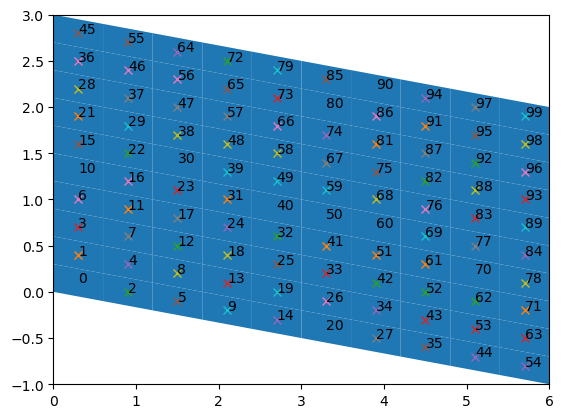

In [2]:
geom = Geometry(3, 6, -1/6)
msh = Geometry.make_domain(geom, 10, 10)
[P0, P1, P2, P3] = geom.corner_points
p = Parameter(msh)
tdim = msh.topology.dim
c2v = msh.topology.connectivity(tdim, 0)
num_cells = msh.topology.index_map(tdim).size_local
cells = np.arange(num_cells, dtype=np.int32)
midpoints = mesh.compute_midpoints(msh, tdim, cells)
x = msh.geometry.x
fig, ax = plt.subplots(1,1)
ax.set_xlim(0, 6)
ax.set_ylim(-1, 3)
for cell, coord in enumerate(midpoints):
    vertices = x[c2v.links(cell)][:,:2]
    polygon = Polygon(np.vstack([vertices[:2], vertices[3], vertices[2]]), closed=False)
    ax.add_patch(polygon)
    ax.plot(coord[0], coord[1], 'x')
    ax.annotate(cell, (coord[0], coord[1]))


2026-06-30 13:59:29.853 (   0.580s) [    78E469C8C600]vtkXOpenGLRenderWindow.:1458  WARN| bad X server connection. DISPLAY=


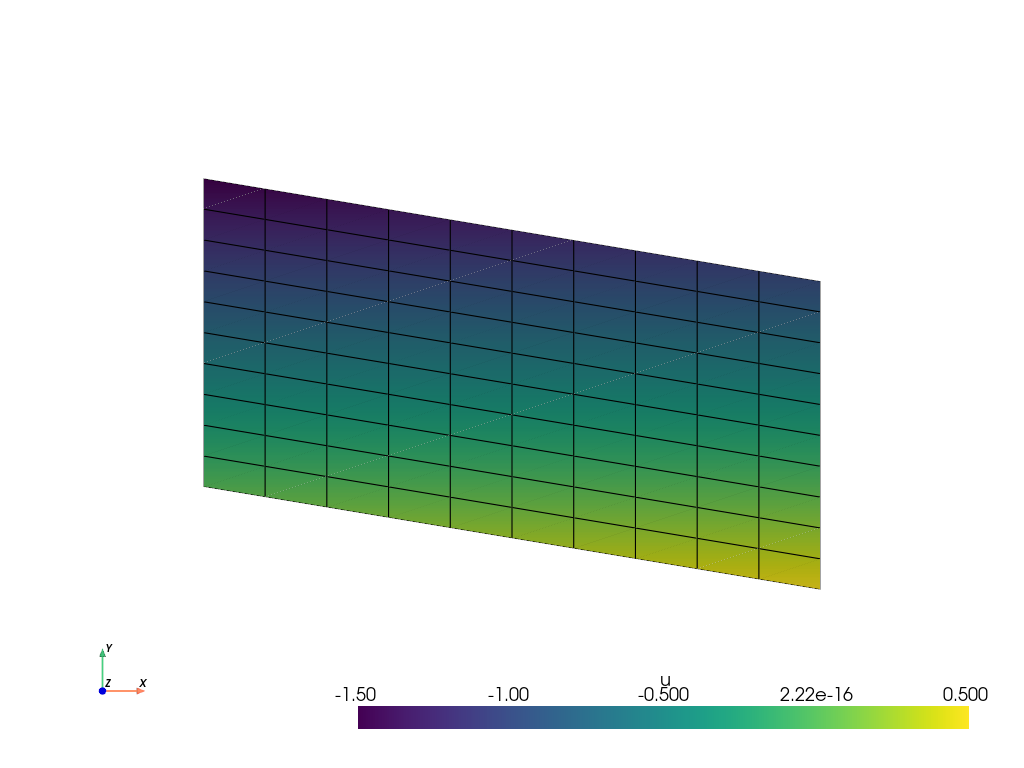

In [3]:
W = functionspace(msh, ("CG", 1))
hw = Function(W)
def ini(x):
    return -0.5*x[1]
hw.interpolate(ini)
plotScalarFunction(W, hw)

h_tot values: [-6.9388939e-18  1.5000000e-01 -5.0000000e-02  1.0000000e-01], h_w values: [-6.9388939e-18 -1.5000000e-01  5.0000000e-02 -1.0000000e-01], max_hw chosen: -0.15000000000000002.
h_tot values: [0.15 0.3  0.1  0.25], h_w values: [-0.15 -0.3  -0.1  -0.25], max_hw chosen: -0.3.
h_tot values: [-0.05  0.1  -0.1   0.05], h_w values: [ 0.05 -0.1   0.1  -0.05], max_hw chosen: -0.1.
h_tot values: [0.3  0.45 0.25 0.4 ], h_w values: [-0.3  -0.45 -0.25 -0.4 ], max_hw chosen: -0.45000000000000007.
h_tot values: [0.1  0.25 0.05 0.2 ], h_w values: [-0.1  -0.25 -0.05 -0.2 ], max_hw chosen: -0.25.
h_tot values: [-1.00000000e-01  5.00000000e-02 -1.50000000e-01 -6.24500451e-17], h_w values: [ 1.00000000e-01 -5.00000000e-02  1.50000000e-01  4.85722573e-17], max_hw chosen: -0.05000000000000002.
h_tot values: [0.45 0.6  0.4  0.55], h_w values: [-0.45 -0.6  -0.4  -0.55], max_hw chosen: -0.6.
h_tot values: [0.25 0.4  0.2  0.35], h_w values: [-0.25 -0.4  -0.2  -0.35], max_hw chosen: -0.40000000000000

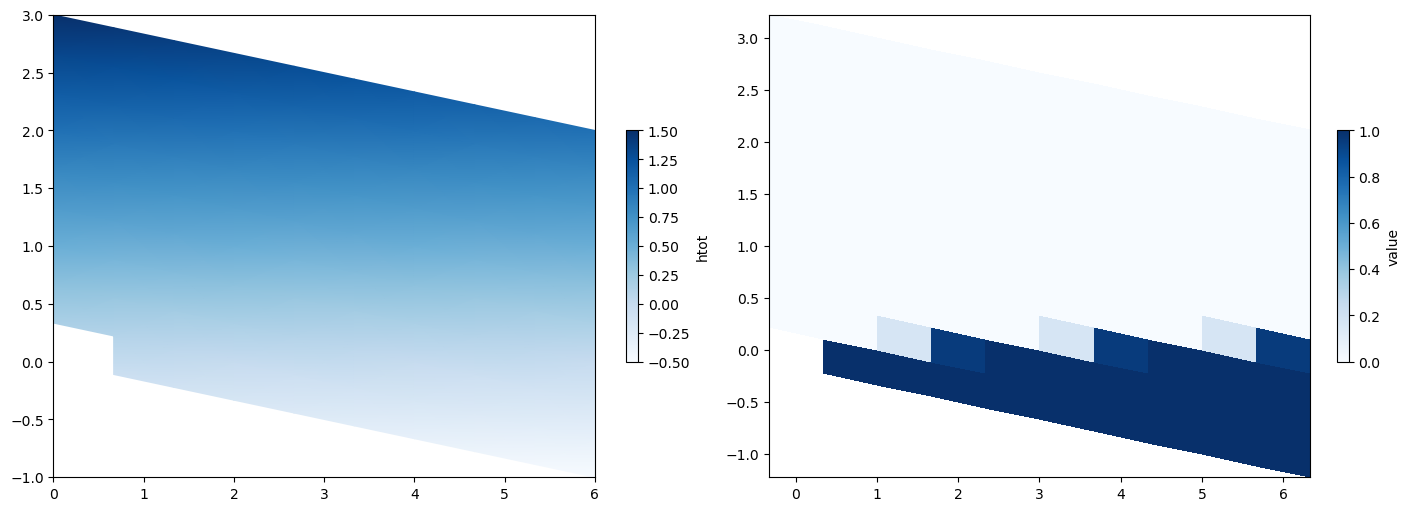

In [7]:
grid, x_plot, z_plot = get_grid(P0, P1, P2, P3, nx=10, nz=10)
h_w = eval_fct_on_grid(grid, hw, msh).reshape((10,10))
h_tot = h_w + z_plot
krel, val = p.upwind_krel(hw, msh)

val_eval = eval_fct_on_grid(grid, val, msh).reshape((10,10))
krel_eval = eval_fct_on_grid(grid, krel, msh).reshape((10,10))
fig, ax = plt.subplots(1,2, layout="constrained", figsize=(14,5))
pmsh1 = ax[0].pcolormesh(x_plot, z_plot, h_tot, cmap="Blues", shading="gouraud")
cbar1 = fig.colorbar(pmsh1, ax=ax[0], shrink=0.5)
cbar1.set_label("htot")

pmsh2 = ax[1].pcolormesh(x_plot, z_plot, krel_eval, cmap="Blues")
cbar2 = fig.colorbar(pmsh2, ax=ax[1], shrink=0.5)
cbar2.set_label("value")

In [6]:
krel.x.array

array([9.55351057e-01, 4.51601029e-07, 9.99821341e-01, 2.17181050e-13,
       2.87601453e-04, 1.00000000e+00, 7.11374956e-18, 1.48911295e-11,
       1.71706193e-01, 1.00000000e+00, 2.36303872e-21, 1.61634995e-16,
       1.79599887e-09, 9.55351057e-01, 1.00000000e+00, 3.39801144e-24,
       2.81199156e-20, 4.94701082e-15, 4.51601029e-07, 9.99821341e-01,
       1.00000000e+00, 1.34319327e-26, 2.64410372e-23, 4.02066096e-19,
       2.17181050e-13, 2.87601453e-04, 1.00000000e+00, 1.00000000e+00,
       1.11297044e-28, 7.73996889e-26, 2.33006148e-22, 7.11374956e-18,
       1.48911295e-11, 1.71706193e-01, 1.00000000e+00, 1.00000000e+00,
       1.62285620e-30, 5.12810396e-28, 4.87933547e-25, 2.36303872e-21,
       1.61634995e-16, 1.79599887e-09, 9.55351057e-01, 1.00000000e+00,
       1.00000000e+00, 3.69854856e-32, 6.29107679e-30, 2.52889272e-27,
       3.39801144e-24, 2.81199156e-20, 4.94701082e-15, 4.51601029e-07,
       9.99821341e-01, 1.00000000e+00, 1.00000000e+00, 1.24859415e-31,
      

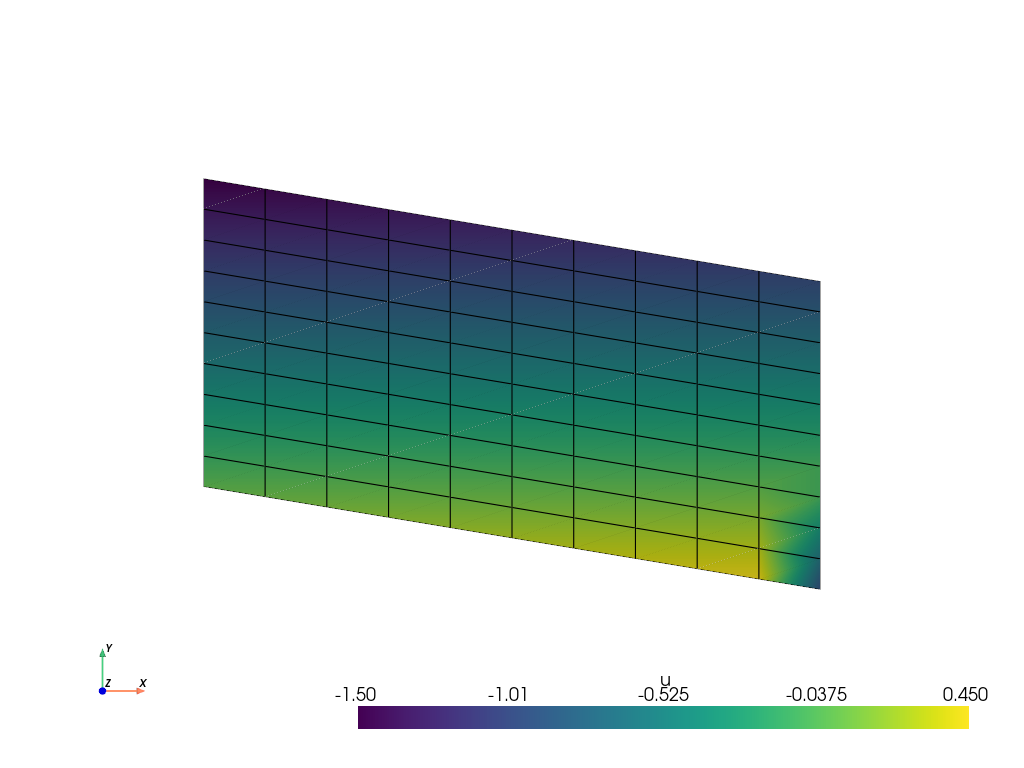

In [13]:
from dolfinx import fem
def on_dirichlet(x):
    return np.logical_and(np.isclose(x[0], P1[0]), x[1] <= 0)
dofsD = fem.locate_dofs_geometrical(W, on_dirichlet)
dofsD
hw.x.array[dofsD] = msh.geometry.x[dofsD][:,1]
plotScalarFunction(W, hw)